# Edge Node Simulation for Distributed IoT Learning

## Overview

This notebook simulates a distributed edge computing architecture for the Secure Water Treatment (SWaT) cyber-physical system.

### Key Concepts:

**SWaT Cyber-Physical System:**
- Industrial water treatment infrastructure with distributed sensors
- 51 IoT sensors monitoring various stages of the purification process
- Each sensor type is strategically located across different treatment stages
- Sensors report measurements at regular intervals (normal readings and attack scenarios)

**Edge Computing Architecture:**
- **Centralized Cloud**: Typically handles global model updates and aggregation
- **Edge Nodes**: Local computing resources that process sensor data independently
- **Edge Benefits**:
  - Reduced latency: Local processing without cloud round-trips
  - Privacy: Sensor data remains at edge, only model updates shared
  - Bandwidth efficiency: Only model parameters transmitted, not raw data
  - Fault tolerance: Edge nodes operate independently if connectivity lost

**Distributed Sensor Groups (Edge Nodes):**
This notebook logically groups the 51 sensors into 6 edge nodes, each representing a cluster of sensors from a specific treatment stage or region:

- **Edge Node 1**: Inlet stage - raw water intake and initial measurement
- **Edge Node 2**: Pre-treatment stage - pH and flow rate monitoring
- **Edge Node 3**: Storage and distribution control
- **Edge Node 4**: Advanced oxidation and disinfection
- **Edge Node 5**: Sensor array 501 - comprehensive measurement redundancy
- **Edge Node 6**: Sensor array 601 - pressure and auxiliary monitoring

**Next Steps:**
Each edge node will train local ML models independently using their subset of sensor features, enabling federated learning experiments across distributed infrastructure.

## Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ Libraries imported successfully")
print(f"  - Pandas: {pd.__version__}")
print(f"  - NumPy: {np.__version__}")

✓ Libraries imported successfully
  - Pandas: 2.3.3
  - NumPy: 1.26.4


## Load Processed Datasets

In [3]:
print("="*80)
print("LOADING PROCESSED DATASETS")
print("="*80)

# Load processed datasets
normal_df = pd.read_csv('data/processed/normal_processed.csv')
attack_df = pd.read_csv('data/processed/attack_processed.csv')

print(f"\n✓ Normal dataset loaded: {normal_df.shape}")
print(f"✓ Attack dataset loaded: {attack_df.shape}")

print(f"\nColumn Names ({len(normal_df.columns)} total):")
print(normal_df.columns.tolist())

print(f"\nFirst 5 rows (Normal Data):")
print(normal_df.head())

print(f"\nDataset Info:")
print(f"  - Normal samples: {len(normal_df):,}")
print(f"  - Attack samples: {len(attack_df):,}")
print(f"  - Total features (including label): {normal_df.shape[1]}")

LOADING PROCESSED DATASETS

✓ Normal dataset loaded: (1387098, 52)
✓ Attack dataset loaded: (54621, 52)

Column Names (52 total):
['FIT101', 'LIT101', ' MV101', 'P101', 'P102', ' AIT201', 'AIT202', 'AIT203', 'FIT201', ' MV201', ' P201', ' P202', 'P203', ' P204', 'P205', 'P206', 'DPIT301', 'FIT301', 'LIT301', 'MV301', 'MV302', ' MV303', 'MV304', 'P301', 'P302', 'AIT401', 'AIT402', 'FIT401', 'LIT401', 'P401', 'P402', 'P403', 'P404', 'UV401', 'AIT501', 'AIT502', 'AIT503', 'AIT504', 'FIT501', 'FIT502', 'FIT503', 'FIT504', 'P501', 'P502', 'PIT501', 'PIT502', 'PIT503', 'FIT601', 'P601', 'P602', 'P603', 'Attack']

First 5 rows (Normal Data):
     FIT101    LIT101     MV101      P101      P102   AIT201    AIT202  \
0  0.511998 -0.539589  0.615277  0.578865 -0.008319  1.40406 -0.272418   
1  0.528937 -0.539263  0.615277  0.578865 -0.008319  1.40406 -0.272418   
2  0.566766 -0.539589  0.615277  0.578865 -0.008319  1.40406 -0.289357   
3  0.606571 -0.538611  0.615277  0.578865 -0.008319  1.40406 

## Clean Column Names

In [4]:
print("="*80)
print("CLEANING COLUMN NAMES")
print("="*80)

# Strip whitespace from column names
print(f"\nBefore cleaning:")
print(f"  Sample column names: {normal_df.columns[:5].tolist()}")

normal_df.columns = normal_df.columns.str.strip()
attack_df.columns = attack_df.columns.str.strip()

print(f"\nAfter cleaning:")
print(f"  Sample column names: {normal_df.columns[:5].tolist()}")

print(f"\n✓ Column names cleaned - whitespace stripped")
print(f"\nCleaned column names ({len(normal_df.columns)} total):")
print(normal_df.columns.tolist())

CLEANING COLUMN NAMES

Before cleaning:
  Sample column names: ['FIT101', 'LIT101', ' MV101', 'P101', 'P102']

After cleaning:
  Sample column names: ['FIT101', 'LIT101', 'MV101', 'P101', 'P102']

✓ Column names cleaned - whitespace stripped

Cleaned column names (52 total):
['FIT101', 'LIT101', 'MV101', 'P101', 'P102', 'AIT201', 'AIT202', 'AIT203', 'FIT201', 'MV201', 'P201', 'P202', 'P203', 'P204', 'P205', 'P206', 'DPIT301', 'FIT301', 'LIT301', 'MV301', 'MV302', 'MV303', 'MV304', 'P301', 'P302', 'AIT401', 'AIT402', 'FIT401', 'LIT401', 'P401', 'P402', 'P403', 'P404', 'UV401', 'AIT501', 'AIT502', 'AIT503', 'AIT504', 'FIT501', 'FIT502', 'FIT503', 'FIT504', 'P501', 'P502', 'PIT501', 'PIT502', 'PIT503', 'FIT601', 'P601', 'P602', 'P603', 'Attack']


## Separate Features and Labels

In [5]:
print("="*80)
print("SEPARATING FEATURES AND LABELS")
print("="*80)

# Identify label column
label_col = 'Attack'

# Separate features and labels
X_normal = normal_df.drop(label_col, axis=1)
y_normal = normal_df[[label_col]]

X_attack = attack_df.drop(label_col, axis=1)
y_attack = attack_df[[label_col]]

print(f"\nNormal Data Split:")
print(f"  - X_normal (features): {X_normal.shape}")
print(f"  - y_normal (labels): {y_normal.shape}")
print(f"  - Label distribution: {y_normal['Attack'].value_counts().to_dict()}")

print(f"\nAttack Data Split:")
print(f"  - X_attack (features): {X_attack.shape}")
print(f"  - y_attack (labels): {y_attack.shape}")
print(f"  - Label distribution: {y_attack['Attack'].value_counts().to_dict()}")

# Store sensor feature names
all_sensors = X_normal.columns.tolist()
print(f"\nTotal sensor features: {len(all_sensors)}")
print(f"Sensors: {all_sensors}")

SEPARATING FEATURES AND LABELS

Normal Data Split:
  - X_normal (features): (1387098, 51)
  - y_normal (labels): (1387098, 1)
  - Label distribution: {0: 1387098}

Attack Data Split:
  - X_attack (features): (54621, 51)
  - y_attack (labels): (54621, 1)
  - Label distribution: {1: 54621}

Total sensor features: 51
Sensors: ['FIT101', 'LIT101', 'MV101', 'P101', 'P102', 'AIT201', 'AIT202', 'AIT203', 'FIT201', 'MV201', 'P201', 'P202', 'P203', 'P204', 'P205', 'P206', 'DPIT301', 'FIT301', 'LIT301', 'MV301', 'MV302', 'MV303', 'MV304', 'P301', 'P302', 'AIT401', 'AIT402', 'FIT401', 'LIT401', 'P401', 'P402', 'P403', 'P404', 'UV401', 'AIT501', 'AIT502', 'AIT503', 'AIT504', 'FIT501', 'FIT502', 'FIT503', 'FIT504', 'P501', 'P502', 'PIT501', 'PIT502', 'PIT503', 'FIT601', 'P601', 'P602', 'P603']


## Define Edge Node Sensor Groups

In [6]:
print("="*80)
print("DEFINING EDGE NODE SENSOR GROUPS")
print("="*80)

# Define sensor groupings for each edge node
# Organized by treatment stage in the SWaT system
edge_node_groups = {
    'Edge_Node_1': ['FIT101', 'LIT101', 'MV101', 'P101', 'P102'],
    'Edge_Node_2': ['AIT201', 'AIT202', 'AIT203', 'FIT201', 'MV201', 'P201', 'P202'],
    'Edge_Node_3': ['FIT301', 'LIT301', 'MV301', 'MV302', 'MV303', 'MV304', 'P301', 'P302'],
    'Edge_Node_4': ['AIT401', 'AIT402', 'FIT401', 'LIT401', 'P401', 'P402', 'P403', 'P404', 'UV401'],
    'Edge_Node_5': ['AIT501', 'AIT502', 'AIT503', 'AIT504', 'FIT501', 'FIT502', 'FIT503', 'FIT504', 'P501', 'P502'],
    'Edge_Node_6': ['PIT501', 'PIT502', 'PIT503', 'FIT601', 'P601', 'P602', 'P603']
}

print(f"\nEdge Node Configuration:")
print(f"  Total edge nodes: {len(edge_node_groups)}\n")

total_mapped_sensors = 0
for node_name, sensors in edge_node_groups.items():
    num_sensors = len(sensors)
    total_mapped_sensors += num_sensors
    print(f"{node_name}:")
    print(f"  - Number of sensors: {num_sensors}")
    print(f"  - Sensors: {sensors}")
    print()

print(f"Summary:")
print(f"  - Total mapped sensors: {total_mapped_sensors}")
print(f"  - Total available sensors: {len(all_sensors)}")
print(f"  - Coverage: {total_mapped_sensors}/{len(all_sensors)}")

# Verify all specified sensors exist in the dataset
print(f"\nValidating sensor availability:")
missing_sensors = []
for node, sensors in edge_node_groups.items():
    for sensor in sensors:
        if sensor not in X_normal.columns:
            missing_sensors.append(sensor)

if missing_sensors:
    print(f"  ⚠ Missing sensors: {missing_sensors}")
else:
    print(f"  ✓ All specified sensors are available in the dataset")

DEFINING EDGE NODE SENSOR GROUPS

Edge Node Configuration:
  Total edge nodes: 6

Edge_Node_1:
  - Number of sensors: 5
  - Sensors: ['FIT101', 'LIT101', 'MV101', 'P101', 'P102']

Edge_Node_2:
  - Number of sensors: 7
  - Sensors: ['AIT201', 'AIT202', 'AIT203', 'FIT201', 'MV201', 'P201', 'P202']

Edge_Node_3:
  - Number of sensors: 8
  - Sensors: ['FIT301', 'LIT301', 'MV301', 'MV302', 'MV303', 'MV304', 'P301', 'P302']

Edge_Node_4:
  - Number of sensors: 9
  - Sensors: ['AIT401', 'AIT402', 'FIT401', 'LIT401', 'P401', 'P402', 'P403', 'P404', 'UV401']

Edge_Node_5:
  - Number of sensors: 10
  - Sensors: ['AIT501', 'AIT502', 'AIT503', 'AIT504', 'FIT501', 'FIT502', 'FIT503', 'FIT504', 'P501', 'P502']

Edge_Node_6:
  - Number of sensors: 7
  - Sensors: ['PIT501', 'PIT502', 'PIT503', 'FIT601', 'P601', 'P602', 'P603']

Summary:
  - Total mapped sensors: 46
  - Total available sensors: 51
  - Coverage: 46/51

Validating sensor availability:
  ✓ All specified sensors are available in the datase

## Create Edge Node Datasets

In [7]:
print("="*80)
print("CREATING EDGE NODE DATASETS")
print("="*80)

# Dictionary to store edge node datasets
edge_datasets = {}

# Create datasets for each edge node
for node_name, sensors in edge_node_groups.items():
    print(f"\nCreating {node_name}...")
    
    # Filter to only available sensors (in case some are missing)
    available_sensors = [s for s in sensors if s in X_normal.columns]
    
    # Create normal dataset for this edge node
    edge_normal = X_normal[available_sensors].copy()
    edge_normal['Attack'] = y_normal['Attack'].values
    
    # Create attack dataset for this edge node
    edge_attack = X_attack[available_sensors].copy()
    edge_attack['Attack'] = y_attack['Attack'].values
    
    # Store in dictionary
    edge_datasets[f"{node_name}_normal"] = edge_normal
    edge_datasets[f"{node_name}_attack"] = edge_attack
    
    print(f"  ✓ Normal dataset: {edge_normal.shape}")
    print(f"  ✓ Attack dataset: {edge_attack.shape}")
    print(f"  ✓ Features: {available_sensors}")

print(f"\n✓ All {len(edge_node_groups)} edge node datasets created successfully")

CREATING EDGE NODE DATASETS

Creating Edge_Node_1...
  ✓ Normal dataset: (1387098, 6)
  ✓ Attack dataset: (54621, 6)
  ✓ Features: ['FIT101', 'LIT101', 'MV101', 'P101', 'P102']

Creating Edge_Node_2...
  ✓ Normal dataset: (1387098, 8)
  ✓ Attack dataset: (54621, 8)
  ✓ Features: ['AIT201', 'AIT202', 'AIT203', 'FIT201', 'MV201', 'P201', 'P202']

Creating Edge_Node_3...
  ✓ Normal dataset: (1387098, 9)
  ✓ Attack dataset: (54621, 9)
  ✓ Features: ['FIT301', 'LIT301', 'MV301', 'MV302', 'MV303', 'MV304', 'P301', 'P302']

Creating Edge_Node_4...
  ✓ Normal dataset: (1387098, 10)
  ✓ Attack dataset: (54621, 10)
  ✓ Features: ['AIT401', 'AIT402', 'FIT401', 'LIT401', 'P401', 'P402', 'P403', 'P404', 'UV401']

Creating Edge_Node_5...
  ✓ Normal dataset: (1387098, 11)
  ✓ Attack dataset: (54621, 11)
  ✓ Features: ['AIT501', 'AIT502', 'AIT503', 'AIT504', 'FIT501', 'FIT502', 'FIT503', 'FIT504', 'P501', 'P502']

Creating Edge_Node_6...
  ✓ Normal dataset: (1387098, 8)
  ✓ Attack dataset: (54621, 8)


## Save Edge Node Datasets

In [8]:
print("="*80)
print("SAVING EDGE NODE DATASETS")
print("="*80)

# Create edge nodes directory
edge_nodes_dir = 'data/processed/edge_nodes'
Path(edge_nodes_dir).mkdir(parents=True, exist_ok=True)
print(f"\n✓ Directory created: {edge_nodes_dir}")

# Save each edge node dataset
print(f"\nSaving datasets:")
for dataset_name, dataset_df in edge_datasets.items():
    file_path = os.path.join(edge_nodes_dir, f"{dataset_name}.csv")
    dataset_df.to_csv(file_path, index=False)
    file_size = os.path.getsize(file_path) / (1024*1024)  # Size in MB
    print(f"  ✓ {dataset_name}.csv - Shape: {dataset_df.shape}, Size: {file_size:.2f} MB")

print(f"\n✓ All edge node datasets saved to: {edge_nodes_dir}/")
print(f"\nSaved files:")
for file in sorted(os.listdir(edge_nodes_dir)):
    print(f"  - {file}")

SAVING EDGE NODE DATASETS

✓ Directory created: data/processed/edge_nodes

Saving datasets:
  ✓ Edge_Node_1_normal.csv - Shape: (1387098, 6), Size: 115.23 MB
  ✓ Edge_Node_1_attack.csv - Shape: (54621, 6), Size: 5.26 MB
  ✓ Edge_Node_2_normal.csv - Shape: (1387098, 8), Size: 108.50 MB
  ✓ Edge_Node_2_attack.csv - Shape: (54621, 8), Size: 6.47 MB
  ✓ Edge_Node_3_normal.csv - Shape: (1387098, 9), Size: 193.04 MB
  ✓ Edge_Node_3_attack.csv - Shape: (54621, 9), Size: 8.32 MB
  ✓ Edge_Node_4_normal.csv - Shape: (1387098, 10), Size: 193.00 MB
  ✓ Edge_Node_4_attack.csv - Shape: (54621, 10), Size: 7.59 MB
  ✓ Edge_Node_5_normal.csv - Shape: (1387098, 11), Size: 238.67 MB
  ✓ Edge_Node_5_attack.csv - Shape: (54621, 11), Size: 9.37 MB
  ✓ Edge_Node_6_normal.csv - Shape: (1387098, 8), Size: 144.27 MB
  ✓ Edge_Node_6_attack.csv - Shape: (54621, 8), Size: 5.70 MB

✓ All edge node datasets saved to: data/processed/edge_nodes/

Saved files:
  - Edge_Node_1_attack.csv
  - Edge_Node_1_normal.csv
  - E

## Edge Node Dataset Statistics

In [9]:
print("="*80)
print("EDGE NODE DATASET STATISTICS")
print("="*80)

# Create statistics summary
stats_list = []

for node_name, sensors in edge_node_groups.items():
    # Filter to available sensors
    available_sensors = [s for s in sensors if s in X_normal.columns]
    num_sensors = len(available_sensors)
    
    # Get normal data for this node
    normal_subset = X_normal[available_sensors]
    normal_samples = len(normal_subset)
    
    # Get attack data for this node
    attack_subset = X_attack[available_sensors]
    attack_samples = len(attack_subset)
    
    # Get labels
    normal_labels = (y_normal['Attack'] == 0).sum()
    attack_labels = (y_attack['Attack'] == 1).sum()
    
    stats_list.append({
        'Edge_Node': node_name,
        'Num_Sensors': num_sensors,
        'Normal_Samples': normal_samples,
        'Attack_Samples': attack_samples,
        'Total_Samples': normal_samples + attack_samples,
        'Normal_Label_Count': normal_labels,
        'Attack_Label_Count': attack_labels,
        'Sensor_List': ', '.join(available_sensors)
    })

# Create statistics dataframe
stats_df = pd.DataFrame(stats_list)

print(f"\nEdge Node Statistics:")
print(stats_df.to_string(index=False))

# Save statistics
stats_output_path = 'results/statistics/edge_node_dataset_summary.csv'
stats_df.to_csv(stats_output_path, index=False)
print(f"\n✓ Statistics saved to: {stats_output_path}")

# Print summary insights
print(f"\nSummary Insights:")
print(f"  - Average sensors per node: {stats_df['Num_Sensors'].mean():.1f}")
print(f"  - Total samples across all nodes: {stats_df['Total_Samples'].sum():,}")
print(f"  - Normal labels: {stats_df['Normal_Label_Count'].sum():,}")
print(f"  - Attack labels: {stats_df['Attack_Label_Count'].sum():,}")

EDGE NODE DATASET STATISTICS

Edge Node Statistics:
  Edge_Node  Num_Sensors  Normal_Samples  Attack_Samples  Total_Samples  Normal_Label_Count  Attack_Label_Count                                                                Sensor_List
Edge_Node_1            5         1387098           54621        1441719             1387098               54621                                          FIT101, LIT101, MV101, P101, P102
Edge_Node_2            7         1387098           54621        1441719             1387098               54621                          AIT201, AIT202, AIT203, FIT201, MV201, P201, P202
Edge_Node_3            8         1387098           54621        1441719             1387098               54621                     FIT301, LIT301, MV301, MV302, MV303, MV304, P301, P302
Edge_Node_4            9         1387098           54621        1441719             1387098               54621              AIT401, AIT402, FIT401, LIT401, P401, P402, P403, P404, UV401
Edge_Node_5  

## Visualize Edge Node Feature Counts

VISUALIZING EDGE NODE SENSOR DISTRIBUTION


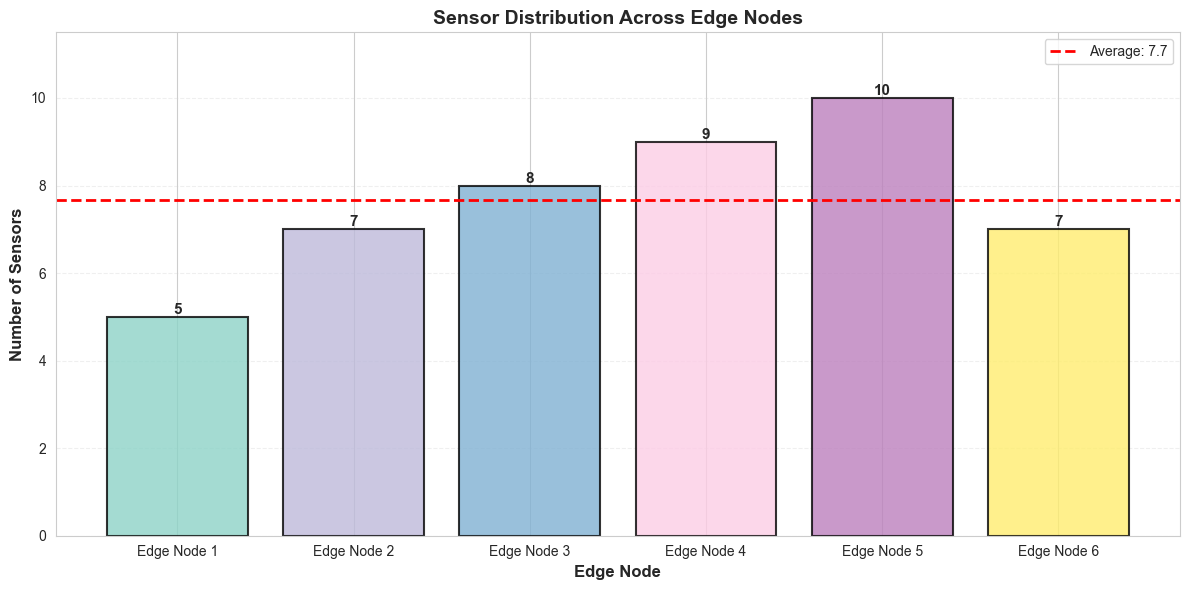


✓ Visualization saved to: results/figures/edge_node_sensor_distribution.png

Sensor Distribution Summary:
  - Minimum sensors per node: 5
  - Maximum sensors per node: 10
  - Average sensors per node: 7.7
  - Total sensors deployed: 46


In [10]:
print("="*80)
print("VISUALIZING EDGE NODE SENSOR DISTRIBUTION")
print("="*80)

# Prepare data for visualization
node_names = [node.replace('_', ' ') for node in edge_node_groups.keys()]
sensor_counts = [len([s for s in sensors if s in X_normal.columns]) for sensors in edge_node_groups.values()]

# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

# Create bar chart
colors = plt.cm.Set3(np.linspace(0, 1, len(node_names)))
bars = ax.bar(node_names, sensor_counts, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)

# Add value labels on bars
for bar, count in zip(bars, sensor_counts):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(count)}',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

# Customize chart
ax.set_xlabel('Edge Node', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Sensors', fontsize=12, fontweight='bold')
ax.set_title('Sensor Distribution Across Edge Nodes', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, max(sensor_counts) * 1.15)

# Add total line
ax.axhline(y=np.mean(sensor_counts), color='red', linestyle='--', linewidth=2, label=f'Average: {np.mean(sensor_counts):.1f}')
ax.legend(fontsize=10)

plt.tight_layout()
fig.savefig('results/figures/edge_node_sensor_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Visualization saved to: results/figures/edge_node_sensor_distribution.png")

print(f"\nSensor Distribution Summary:")
print(f"  - Minimum sensors per node: {min(sensor_counts)}")
print(f"  - Maximum sensors per node: {max(sensor_counts)}")
print(f"  - Average sensors per node: {np.mean(sensor_counts):.1f}")
print(f"  - Total sensors deployed: {sum(sensor_counts)}")

## Final Summary

In [11]:
print("="*80)
print("EDGE NODE SIMULATION - FINAL SUMMARY")
print("="*80)

print(f"\n📊 EDGE NODE CONFIGURATION:")
print(f"  ✓ Total edge nodes: {len(edge_node_groups)}")
print(f"  ✓ Total sensors distributed: {sum(len([s for s in sensors if s in X_normal.columns]) for sensors in edge_node_groups.values())}")
print(f"  ✓ Average sensors per node: {np.mean(sensor_counts):.1f}")

print(f"\n📁 DATASETS CREATED:")
print(f"  ✓ Edge node datasets: {len(edge_datasets)}")
print(f"    - {len(edge_datasets)//2} normal datasets")
print(f"    - {len(edge_datasets)//2} attack datasets")
print(f"  ✓ Location: data/processed/edge_nodes/")

print(f"\n📈 SAMPLES DISTRIBUTION:")
print(f"  Total normal samples: {X_normal.shape[0]:,}")
print(f"  Total attack samples: {X_attack.shape[0]:,}")
print(f"  Combined total: {X_normal.shape[0] + X_attack.shape[0]:,}")

print(f"\n🎯 INDIVIDUAL EDGE NODE STATISTICS:")
for idx, (node_name, sensors) in enumerate(edge_node_groups.items(), 1):
    available_sensors = [s for s in sensors if s in X_normal.columns]
    print(f"  {node_name}:")
    print(f"    - Sensors: {len(available_sensors)}")
    print(f"    - Sensor names: {', '.join(available_sensors)}")
    print()

print(f"📂 OUTPUT FILES GENERATED:")
print(f"  Processed Datasets:")
for i in range(1, len(edge_node_groups) + 1):
    print(f"    • data/processed/edge_nodes/Edge_Node_{i}_normal.csv")
    print(f"    • data/processed/edge_nodes/Edge_Node_{i}_attack.csv")
print(f"\n  Statistics:")
print(f"    • results/statistics/edge_node_dataset_summary.csv")
print(f"\n  Visualizations:")
print(f"    • results/figures/edge_node_sensor_distribution.png")

print(f"\n🚀 NEXT STEPS:")
print(f"  These edge node datasets are now ready for:")
print(f"  ✓ Local ML model training on each edge node")
print(f"  ✓ Distributed federated learning experiments")
print(f"  ✓ Edge-to-cloud model aggregation simulations")
print(f"  ✓ Anomaly detection and intrusion detection evaluation")

print(f"\n" + "="*80)
print(f"✓ EDGE NODE SIMULATION COMPLETE")
print(f"="*80)
print(f"\nAll edge nodes are configured and ready for federated learning!")

EDGE NODE SIMULATION - FINAL SUMMARY

📊 EDGE NODE CONFIGURATION:
  ✓ Total edge nodes: 6
  ✓ Total sensors distributed: 46
  ✓ Average sensors per node: 7.7

📁 DATASETS CREATED:
  ✓ Edge node datasets: 12
    - 6 normal datasets
    - 6 attack datasets
  ✓ Location: data/processed/edge_nodes/

📈 SAMPLES DISTRIBUTION:
  Total normal samples: 1,387,098
  Total attack samples: 54,621
  Combined total: 1,441,719

🎯 INDIVIDUAL EDGE NODE STATISTICS:
  Edge_Node_1:
    - Sensors: 5
    - Sensor names: FIT101, LIT101, MV101, P101, P102

  Edge_Node_2:
    - Sensors: 7
    - Sensor names: AIT201, AIT202, AIT203, FIT201, MV201, P201, P202

  Edge_Node_3:
    - Sensors: 8
    - Sensor names: FIT301, LIT301, MV301, MV302, MV303, MV304, P301, P302

  Edge_Node_4:
    - Sensors: 9
    - Sensor names: AIT401, AIT402, FIT401, LIT401, P401, P402, P403, P404, UV401

  Edge_Node_5:
    - Sensors: 10
    - Sensor names: AIT501, AIT502, AIT503, AIT504, FIT501, FIT502, FIT503, FIT504, P501, P502

  Edge_Nod